**420-C74-SF - Techniques d'apprentissage automatique - Automne 2026 - Spécialiste en solutions d'intelligence artificielle**<br/>
© 2026 MKL.AI - Tous droits réservés
<br/>
![Atelier - Régression linéaire multiple](static/04-A-banner.png)
<br/>
**Objectif:** cette séance de travaux pratique consiste en la mise en oeuvre sous forme de code vectorisé de l'**algorithme du gradient en régression linéaire multiple**. Le jeu de données utilisé sera la version complète du jeu de données *Advertising* et devra être **mis à l'échelle**

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

### 0 - Chargement des bibliothèques

In [2]:
# Manipulation de données
import numpy as np
import pandas as pd
from collections import defaultdict

# Visualisation de données
import matplotlib.pyplot as plt
import seaborn as sns

# Outils divers
from tqdm.notebook import tqdm_notebook
from tqdm import tqdm

In [3]:
# Configuration de la visualisation
sns.set(style="darkgrid", rc={'figure.figsize':(11.7,8.27)})

### 1 - Lecture du jeu de données advertising

**Exercice 1-1**: à l'aide de la bibiothèques *pandas*, lire le fichier `advertising-multivariate.csv`

In [9]:
# Compléter le code ci-dessous ~ 1 ligne
#df = pd.read_csv('../../data/advertising-multivariate.csv')
df = pd.read_csv('../../data/advertising-multivariate.csv', usecols=['TV','radio','newspaper','sales'])

**Exercice 1-2**: à l'aide de la fonction `head()`, visualiser les premières lignes de la trame de données. Quelle sera la taille du vecteur de paramètres $\theta$ ?

In [10]:
# Compléter le code ci-dessous ~ 1 ligne
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


### 2 - Mise à l'échelle des données

**Exercice 2**: Standardiser les données.<br/>
Note: Il n'est pas nécéssaire de standardiser la variable de sortie, mais vous pouvez le faire à des fins de simplification

In [20]:
# Compléter le code ci-dessous ~ 1 ligne

df_norm = (df - df.mean(axis=0)) / df.std(axis=0)
df_norm.head()

,TV,radio,newspaper,sales
0,0.967425,0.979066,1.774493,1.548168
1,-1.194379,1.080097,0.667903,-0.694304
2,-1.512360,1.524637,1.779084,-0.905135
3,0.051919,1.214806,1.283185,0.858177
4,0.393196,-0.839507,1.278593,-0.215143


### 3 - Préparation de la structure de données

**Exercice 3**: Construire la matrice des prédicteurs X sans oublier d'ajouter une colonne représentant $x_0$

In [31]:
# Compléter le code ci-dessous ~ 5 lignes
x0 = np.ones(shape=(200))
x1 = df_norm['TV'].values
x2 = df_norm['radio'].values
x3 = df_norm['newspaper'].values
X = np.stack((x0,x1,x2,x3), axis=1)

y = df['sales'].values.reshape(-1,1) # Nous gardons ici les valeurs non standardisées
y.shape

(200, 1)

<strong style='color: green'>TEST - Le code ci-dessous vous permet de tester la forme de `X`. Le `assert` ne doit pas renvoyer d'exception</strong>

In [32]:
assert X.shape == (200,4)

### 4 - Définition du modèle

**Exercice 4**: compléter la fonction ci-dessous représentant le modèle de régression linéaire multiple (hypothèse)

Pour rappel, le modèle de régression multiple est

$h_{\theta}(x)=\theta_{0}x_0 + \theta_{1}x_1 + \cdots + \theta_{n}x_n = \theta^TX$

In [38]:
def hypothesis(x, theta):
    assert x.shape[1] == theta.shape[0]
    # Compléter le code ~ 1 ligne
    h = np.dot(x, theta)
    #h = x @ theta
    return h

<strong style='color: green'>TEST - Le code ci-dessous vous permet de tester votre fonction `hypothesis`. Le `assert` ne doit pas renvoyer d'exception</strong>

In [39]:
x_test = np.array([[1,1],[3,4],[2,2],[1,-1]])
theta_test = np.array([1,2]).reshape(-1,1)
hypothesis(x_test, theta_test)
assert np.array_equal(hypothesis(x_test,theta_test), np.array([[3],[11],[6],[-1]]))

### 5 - Fonction de coût

**Exercice 5**: compléter la fonction ci-dessous permettant le calcul du coût (fonction de coût)

Pour rappel, la fonction de coût en régression linéaire multiple s'exprime sous la forme

$J(\theta)= \frac{1}{2m}\sum\limits_{i=1}^{m}(h_{\theta}(x^{(i)})-y^{(i)})^{2}=\frac{1}{2m}(y-X\theta)^T\times(y-X\theta)$

Remarque: comme le montre l'équation ci-dessus, il exite deux méthodes pour calculer la fonction de coût. Choisissez celle qui vous convient.<br/><em>Optionnel: faites l'autre méthode</em>

In [52]:
def cost_function(x,y, theta):
    # Compléter le code ~ 1-4 lignes
    error = y - np.dot(X,theta)
    sse = np.dot(error.T, error) 
    cost = (1/(2*y.shape[0])) * sse.squeeze()
    return cost

<strong style='color: green'>TEST - Le code ci-dessous permet de tester la fonction `cost_function`. Celle-ci doit retourner un `numpy.float64`, c'est-à-dire un nombre et non tableau (array). Le `assert` ne doit pas renvoyer d'exception et le résultat attendu est ~ 94.92</strong>

In [53]:
theta_test = np.array([1,2,2,4]).reshape(-1,1)
cost = cost_function(X,y,theta_test)
assert type(cost) == np.float64
cost

np.float64(94.91820816343485)

### 6 - Algorithme du gradient

**Exercice 6**: Compléter l'algorithme du gradient ci-dessous. Choisir le vecteur $\theta$ initial, la valeurs du **pas** ($\alpha$) et le **nombre d'itérations**. Un test de convergence ne sera pas utilisé ici.

$$
\begin{aligned}
&\text{Répéter pendant n\_iterations} \; \{\\
&\theta_{j} := \theta_{j} - \alpha\frac{1}{m}\sum_{i=1}^{m}\left(h_{\theta}(x^{(i)})-y^{(i)}\right) x_{j}^{(i)} \quad \forall j\\
&\}
\end{aligned}
$$

Ou sous forme vectorisée:

$$
\begin{aligned}
&\text{Répéter pendant n\_iterations} \; \{\\
&\theta := \theta - \alpha\frac{1}{m} X^{T}\left(X\theta - y\right)\\
&\}
\end{aligned}
$$

<strong>Vous êtes vivement encouragés à utiliser la forme vectorisée.

In [76]:
theta = np.zeros(shape = (X.shape[1],1))
alpha = 0.2
n_iterations = 500

m = y.shape[0]

history = defaultdict(list)

for i in tqdm(range(0, n_iterations)):
    
    # Compléter le code ~ 2 lignes
    d_theta = np.dot((hypothesis(X, theta) - y).T, X) / m
    theta = theta - (alpha * d_theta.T)
    
    # Sauvegarde des valeurs intermédiaires de theta et du coût
    if i%2 == 0:
        cost = cost_function(X, y, theta)
        history['theta_0'].append(theta[0])
        history['theta_1'].append(theta[1])
        history['theta_2'].append(theta[2])
        history['theta_3'].append(theta[3])
        history['cost'].append(cost)
        
print(f'Theta = {theta}')

100%|█████████████████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 94423.77it/s]

Theta = [[14.0225    ]
 [ 3.92908869]
 [ 2.79906919]
 [-0.02259517]]


Les valeurs des paramètres $\theta_j$ devraient approcher

```[[14.0225    ]
 [ 3.92908869]
 [ 2.79906919]
 [-0.02259517]]```

Text(0.5, 0, 'Itérations')

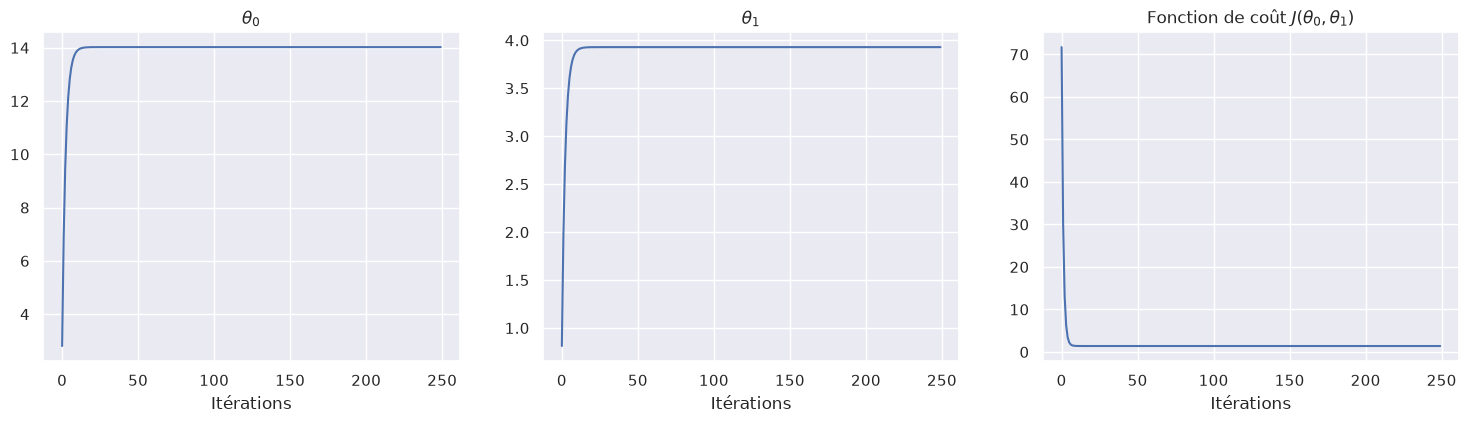

In [77]:
sns.set(rc={'figure.figsize':(18.27,4.27)})
f, (ax1, ax2, ax3) = plt.subplots(1, 3)
ax1.plot(history['theta_0'])
ax1.set_title(r'$\theta_{0}$')
ax1.set_xlabel('Itérations')
ax2.plot(history['theta_1'])
ax2.set_title(r'$\theta_{1}$')
ax2.set_xlabel('Itérations')
ax3.plot(history['cost'])
ax3.set_title(r'Fonction de coût $J(\theta_{0},\theta_{1})$')
ax3.set_xlabel('Itérations')

### 7 - Interprétation des paramètres

**Exercice 7**: Interpréter les paramètres obtenus

### Fin de l'atelier